In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#link do strony z tutorialem: https://tutorials.deepmodeling.com/en/latest/Tutorials/DeePMD-kit/learnDoc/Handson-Tutorial%28v2.0.3%29.html

In [ ]:
!pip install ase
!pip install dpdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y tensorflow deepmd-kit
!pip install tensorflow==2.21.0 deepmd-kit --no-binary deepmd-kit

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.1 MB/s eta 0:00:00
Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.9 MB)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)

import deepmd
print("DeepMD imported successfully")

TensorFlow: 2.21.0
DeepMD imported successfully


In [ ]:
import pandas as pd
df=pd.read_csv('/content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz')
df=pd.read_csv('/content/gdrive/MyDrive/ML/task-2/forces_298.xyz')

### Content of `trajectory.xyz`

In [ ]:
file_path_trajectory_298 = '/content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz'

print(f"Displaying first 10 lines of {file_path_trajectory_298}:")
with open(file_path_trajectory_298, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())


Displaying first 10 lines of /content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz:
10
# ORCA AIMD Position Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Angstrom
H     -2.5898860495     -0.5548979311     -0.4381717129
C     -1.8883686880     -1.4254214536     -0.4362223298
O     -1.2200390767     -1.6934440470      0.5682407369
O     -1.8866384608     -2.0650807788     -1.5750642937
H     -1.2259610993     -2.8659555634     -1.5377286697
H     -0.2355286972     -2.8823536232      0.6351176207
O      0.4246675954     -3.6836300881      0.6725367249
C      0.4258180534     -4.3236834913     -0.4661098869


In [ ]:
file_path_trajectory_500 = '/content/gdrive/MyDrive/ML/task-2/trajectory_500.xyz'

print(f"Displaying first 10 lines of {file_path_trajectory_500}:")
with open(file_path_trajectory_500, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

Displaying first 10 lines of /content/gdrive/MyDrive/ML/task-2/trajectory_500.xyz:
10
# ORCA AIMD Position Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Angstrom
H     -2.5898860495     -0.5548979311     -0.4381717129
C     -1.8883686880     -1.4254214536     -0.4362223298
O     -1.2200390767     -1.6934440470      0.5682407369
O     -1.8866384608     -2.0650807788     -1.5750642937
H     -1.2259610993     -2.8659555634     -1.5377286697
H     -0.2355286972     -2.8823536232      0.6351176207
O      0.4246675954     -3.6836300881      0.6725367249
C      0.4258180534     -4.3236834913     -0.4661098869


In [ ]:
file_path_forces_298 = '/content/gdrive/MyDrive/ML/task-2/forces_298.xyz'

print(f"Displaying first 10 lines of {file_path_forces_298}:")
with open(file_path_forces_298, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())


Displaying first 10 lines of /content/gdrive/MyDrive/ML/task-2/forces_298.xyz:
10
# ORCA AIMD Force Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Hartree/Angstrom
H      0.0000000000      0.0000000000      0.0000000000
C      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
H      0.0000000000      0.0000000000      0.0000000000
H      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
C      0.0000000000      0.0000000000      0.0000000000


In [ ]:
file_path_forces_500 = '/content/gdrive/MyDrive/ML/task-2/forces_500.xyz'

print(f"Displaying first 10 lines of {file_path_forces_500}:")
with open(file_path_forces_500, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

Displaying first 10 lines of /content/gdrive/MyDrive/ML/task-2/forces_500.xyz:
10
# ORCA AIMD Force Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Hartree/Angstrom
H      0.0000000000      0.0000000000      0.0000000000
C      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
H      0.0000000000      0.0000000000      0.0000000000
H      0.0000000000      0.0000000000      0.0000000000
O      0.0000000000      0.0000000000      0.0000000000
C      0.0000000000      0.0000000000      0.0000000000


In [ ]:
import ase.io
import dpdata
import numpy as np
import os
import re

# =========================
# Ścieżki do plików wejściowych
# =========================

file_path_trajectory_298 = "/content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz"
file_path_forces_298 = "/content/gdrive/MyDrive/ML/task-2/forces_298.xyz"

file_path_trajectory_500 = "/content/gdrive/MyDrive/ML/task-2/trajectory_500.xyz"
file_path_forces_500 = "/content/gdrive/MyDrive/ML/task-2/forces_500.xyz"

# Nowy folder wyjściowy
base_npy_folder = "/content/gdrive/MyDrive/ML/task-2/npy_change"

# =========================
# Stałe do konwersji jednostek
# =========================

HARTREE_TO_EV = 27.211386245988
BOHR_TO_ANGSTROM = 0.529177210903


def read_orca_forces_and_energies(forces_path, atom_symbols=("H", "C", "O")):
    """
    Czyta energie i siły z pliku forces_XXX.xyz z ORCA AIMD.

    Energia:
        Hartree -> eV

    Siły:
        Hartree/Angstrom -> eV/Angstrom

    Jeśli w nagłówku byłoby Hartree/Bohr, kod też to obsłuży.
    """

    energies_hartree = []
    forces_raw = []
    force_unit = None

    # Szuka dokładnie fragmentu E_Pot=-378.877...
    energy_pattern = re.compile(
        r"E_Pot\s*=\s*([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][+-]?\d+)?)"
    )

    with open(forces_path, "r") as f:
        for line in f:
            line_stripped = line.strip()

            if not line_stripped:
                continue

            # Czytanie energii z nagłówka ramki
            match = energy_pattern.search(line_stripped)

            if match:
                energy_hartree = float(match.group(1))
                energies_hartree.append(energy_hartree)

                # Rozpoznanie jednostki sił z nagłówka
                if "Hartree/Angstrom" in line_stripped or "Hartree/Ang" in line_stripped:
                    force_unit = "Hartree/Angstrom"
                elif "Hartree/Bohr" in line_stripped:
                    force_unit = "Hartree/Bohr"

            # Czytanie sił z linii atomowych:
            # C   fx   fy   fz
            # H   fx   fy   fz
            # O   fx   fy   fz
            parts = line_stripped.split()

            if len(parts) >= 4 and parts[0] in atom_symbols:
                try:
                    fx = float(parts[1])
                    fy = float(parts[2])
                    fz = float(parts[3])
                    forces_raw.append([fx, fy, fz])
                except ValueError:
                    pass

    energies_hartree = np.array(energies_hartree, dtype=float)
    forces_raw = np.array(forces_raw, dtype=float)

    # Energia: Hartree -> eV
    energies_ev = energies_hartree * HARTREE_TO_EV

    # Siły: do eV/Angstrom
    if force_unit == "Hartree/Angstrom":
        forces_ev_angstrom = forces_raw * HARTREE_TO_EV

    elif force_unit == "Hartree/Bohr":
        forces_ev_angstrom = forces_raw * (HARTREE_TO_EV / BOHR_TO_ANGSTROM)

    else:
        raise ValueError(
            f"Nie rozpoznano jednostki sił w pliku: {forces_path}. "
            "Sprawdź, czy w nagłówku jest tekst typu 'Unit is Hartree/Angstrom'."
        )

    return energies_ev, forces_ev_angstrom


def process_deepmd_data(trajectory_path, forces_path, output_dir_name):
    print(f"\n--- Processing data for: {output_dir_name} ---")
    print("Trajectory file:", trajectory_path)
    print("Forces file:", forces_path)

    # 1. Wczytanie trajektorii przez ASE
    ase_data = ase.io.read(trajectory_path, index=":", format="extxyz")

    data = dpdata.System()

    for atoms in ase_data:
        frame = dpdata.System(atoms, fmt="ase/structure")
        data.append(frame)

    expected_num_frames = len(data)
    natoms = data.get_natoms()

    print("Number of frames in trajectory:", expected_num_frames)
    print("Number of atoms:", natoms)

    # 2. Wczytanie energii i sił z pliku ORCA
    energies_ev, forces_ev_angstrom_flat = read_orca_forces_and_energies(forces_path)

    print("Number of energies found:", len(energies_ev))
    print("Number of force vectors found:", len(forces_ev_angstrom_flat))

    # 3. Sprawdzenie liczby energii
    if len(energies_ev) > expected_num_frames:
        print(
            f"Warning: found {len(energies_ev)} energies, "
            f"but trajectory has {expected_num_frames} frames. "
            "Extra energies will be ignored."
        )
        energies_ev = energies_ev[:expected_num_frames]

    elif len(energies_ev) < expected_num_frames:
        raise ValueError(
            f"Mismatch in number of energies. "
            f"Expected {expected_num_frames}, found {len(energies_ev)}."
        )

    # 4. Sprawdzenie liczby wektorów sił
    expected_num_force_vectors = expected_num_frames * natoms

    if len(forces_ev_angstrom_flat) > expected_num_force_vectors:
        print(
            f"Warning: found {len(forces_ev_angstrom_flat)} force vectors, "
            f"but expected {expected_num_force_vectors}. "
            "Extra force vectors will be ignored."
        )
        forces_ev_angstrom_flat = forces_ev_angstrom_flat[:expected_num_force_vectors]

    elif len(forces_ev_angstrom_flat) < expected_num_force_vectors:
        raise ValueError(
            f"Mismatch in number of force vectors. "
            f"Expected {expected_num_force_vectors}, found {len(forces_ev_angstrom_flat)}."
        )

    # 5. Zmiana kształtu sił na format: frames x atoms x 3
    forces_ev_angstrom = forces_ev_angstrom_flat.reshape(
        expected_num_frames,
        natoms,
        3
    )

    # 6. Przypisanie energii i sił do obiektu dpdata
    data.data["energies"] = energies_ev
    data.data["forces"] = forces_ev_angstrom

    # 7. Zapis do nowego folderu npy_change/FAD_XXX
    final_output_path = os.path.join(base_npy_folder, output_dir_name)

    os.makedirs(final_output_path, exist_ok=True)

    data.to_deepmd_npy(final_output_path)

    print(f"\nSaved DeepMD npy data to:")
    print(final_output_path)

    # 8. Kontrola zapisanych danych
    energy_path = os.path.join(final_output_path, "set.000", "energy.npy")
    force_path = os.path.join(final_output_path, "set.000", "force.npy")
    coord_path = os.path.join(final_output_path, "set.000", "coord.npy")

    energy_check = np.load(energy_path)
    force_check = np.load(force_path)
    coord_check = np.load(coord_path)

    print("\nCheck saved files:")
    print("energy shape:", energy_check.shape)
    print("force shape:", force_check.shape)
    print("coord shape:", coord_check.shape)

    print("\nFirst 5 energies in eV:")
    print(energy_check[:5].flatten())

    print("\nEnergy min/max in eV:")
    print(energy_check.min(), energy_check.max())

    print("\nForce min/max in eV/Angstrom:")
    print(force_check.min(), force_check.max())

    print("\ntype_map.raw:")
    with open(os.path.join(final_output_path, "type_map.raw")) as f:
        print(f.read())

    print("type.raw:")
    with open(os.path.join(final_output_path, "type.raw")) as f:
        print(f.read())

    print(f"\n# Successfully processed {expected_num_frames} frames for {output_dir_name}.")
    print(f"# Use this path in input.json: {final_output_path}")


# =========================
# Uruchomienie konwersji
# =========================

process_deepmd_data(
    file_path_trajectory_298,
    file_path_forces_298,
    "FAD_298"
)

process_deepmd_data(
    file_path_trajectory_500,
    file_path_forces_500,
    "FAD_500"
)


--- Processing data for: FAD_298 ---
Trajectory file: /content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz
Forces file: /content/gdrive/MyDrive/ML/task-2/forces_298.xyz
Number of frames in trajectory: 1001
Number of atoms: 10
Number of energies found: 1001
Number of force vectors found: 10010


KeyboardInterrupt: 

In [ ]:
import ase.io
import ase
import dpdata
import numpy as np
import os

# Define full paths for the files
file_path_trajectory_298 = '/content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz'
file_path_forces_298 = '/content/gdrive/MyDrive/ML/task-2/forces_298.xyz'
file_path_trajectory_500 = '/content/gdrive/MyDrive/ML/task-2/trajectory_500.xyz'
file_path_forces_500 = '/content/gdrive/MyDrive/ML/task-2/forces_500.xyz'

def process_deepmd_data(trajectory_path, forces_path, output_dir_name):
    print(f"\n--- Processing data for: {trajectory_path} and {forces_path} ---")

    # 1. Load structures via ASE into dpdata
    ase_data = ase.io.read(trajectory_path, index=":", format="extxyz")
    data = dpdata.System()
    for atoms in ase_data:
        data.append(dpdata.System(atoms, fmt="ase/structure"))

    # 2. Open force file once and extract energies and forces in a single pass
    with open(forces_path, "r") as f:
        lines = [line.strip().split() for line in f if line.strip()]

    extracted_energies = [float(l[6].split("=")[1]) for l in lines if "E_Pot=" in "".join(l)]
    extracted_forces = [[float(x) for x in l[1:4]] for l in lines if len(l) >= 4 and l[0] in ['C', 'H', 'O']]

    # Validate and assign energies
    expected_num_frames = len(data)
    energies_to_assign = np.array(extracted_energies)

    if len(energies_to_assign) > expected_num_frames:
        print(f"Warning: {forces_path} contains {len(energies_to_assign) - expected_num_frames} extra energy entries which will be ignored to match {trajectory_path} frames.")
        energies_to_assign = energies_to_assign[:expected_num_frames]
    elif len(energies_to_assign) < expected_num_frames:
        raise ValueError(f"Mismatch in number of energies. Expected {expected_num_frames}, but found {len(energies_to_assign)}. Check {forces_path} file structure.")

    # Validate and assign forces
    expected_num_force_vectors = expected_num_frames * data.get_natoms()
    forces_to_assign = np.array(extracted_forces)

    if len(forces_to_assign) > expected_num_force_vectors:
        print(f"Warning: {forces_path} contains {len(forces_to_assign) - expected_num_force_vectors} extra force entries which will be ignored to match {trajectory_path} frames.")
        forces_to_assign = forces_to_assign[:expected_num_force_vectors]
    elif len(forces_to_assign) < expected_num_force_vectors:
        raise ValueError(f"Mismatch in number of forces. Expected {expected_num_force_vectors} force vectors, but found {len(forces_to_assign)}. Check {forces_path} file structure.")

    # 3. Direct dictionary binding and export
    data.data['energies'] = energies_to_assign
    data.data['forces'] = forces_to_assign.reshape(expected_num_frames, data.get_natoms(), 3)

    # The base path for the .npy data in Google Drive
    base_npy_folder = '/content/gdrive/MyDrive/ML/task-2/npy'
    # The final output path for each dataset (e.g., /.../npy/FAD_298)
    final_output_path = os.path.join(base_npy_folder, output_dir_name)

    os.makedirs(final_output_path, exist_ok=True) # Ensure the FAD_XXX directory exists

    # Export data using 'deepmd/npy' format.
    # The 'set_prefix' argument should point to the FAD_XXX directory.
    # dpdata will automatically create 'set.000' and other necessary files inside this 'folder'.
    data.to('deepmd/npy', set_prefix=final_output_path, file_name='data')

    print(f'# Successfully processed {len(data)} frames for {output_dir_name} with real labels.')

# Process the 298K data
process_deepmd_data(file_path_trajectory_298, file_path_forces_298, 'FAD_298')

# Process the 500K data
process_deepmd_data(file_path_trajectory_500, file_path_forces_500, 'FAD_500')

In [ ]:
cat /content/gdrive/MyDrive/ML/task-2/npy_change/FAD_500/type.raw

In [ ]:
cat /content/gdrive/MyDrive/ML/task-2/npy_change/FAD_500/type_map.raw

In [ ]:
cat /content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298/type.raw

0
1
2
2
0
0
2
1
2
0


Training data on 500K -> make input json
training data: folder 500K
validation data: folder 298K

In [ ]:
import json
import os

# The configuration data as a Python dictionary
input_config = {
    "model": {
        "type_map": ["H", "C","O"],
        "descriptor": {
            "type": "se_e2_a",
            "rcut": 6.00,
            "rcut_smth": 0.50,
            "sel": [1, 4, 2],
            "neuron": [10, 20, 40],
            "resnet_dt": False,
            "axis_neuron": 4,
            "seed": 1,
            "_comment": "that's all"
        },
        "fitting_net": {
            "neuron": [100, 100, 100],
            "resnet_dt": True,
            "seed": 1,
            "_comment": "that's all"
        },
        "_comment": "that's all"
    },
    "learning_rate": {
        "type": "exp",
        "decay_steps": 5000,
        "start_lr": 0.001,
        "stop_lr": 3.51e-8,
        "_comment": "that's all"
    },
    "loss": {
        "type": "ener",
        "start_pref_e": 0.02,
        "limit_pref_e": 1,
        "start_pref_f": 1000,
        "limit_pref_f": 1,
        "start_pref_v": 0,
        "limit_pref_v": 0,
        "_comment": "that's all"
    },
    "training": {
        "training_data": {
            "systems": ["/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_500"], #training data
            "batch_size": "auto",
            "_comment": "that's all"
        },
        "validation_data": {
            "systems": ["/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298"], #validation data
            "batch_size": "auto",
            "numb_btch": 1,
            "_comment": "that's all"
        },
        "numb_steps": 50000,
        "seed": 10,
        "disp_file": "lcurve.out",
        "disp_freq": 1000,
        "save_freq": 10000
    }
}

# Define the output file path
output_json_path = '/content/gdrive/MyDrive/ML/task-2/input.json'

# Ensure the directory exists (optional, as the parent dir should exist from previous steps)
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# Write the dictionary to a JSON file
with open(output_json_path, 'w') as f:
    json.dump(input_config, f, indent=4)

print(f"DeepMD input configuration saved to: {output_json_path}")

In [ ]:
%cd /content/gdrive/MyDrive/ML/task-2/out

Now that `deepmd-kit` is installed and the `input.json` file is ready, you can start the DeepMD training using the `dp train` command:

In [ ]:
# Run the DeepMD training using the generated input.json file
!dp train /content/gdrive/MyDrive/ML/task-2/input.json

In [ ]:
!find /content -name "lcurve.out"

/content/gdrive/MyDrive/ML/task-2/out/lcurve.out
find: ‘/content/drive’: Transport endpoint is not connected


In [ ]:
 cat lcurve.out

cat: lcurve.out: No such file or directory


In [ ]:
#restartowanie obliczeni z json.input: dp train  --restart model.ckpt  input.json

In [ ]:
import numpy as np

path = "/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298"

energy = np.load(path + "/set.000/energy.npy")
force = np.load(path + "/set.000/force.npy")

print("Pierwsze energie:")
print(energy[:5])

print("\nZakres energii:")
print(energy.min(), energy.max())

print("\nZakres sił:")
print(force.min(), force.max())

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298/set.000/energy.npy'

In [ ]:
import numpy as np

path = "/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298"

energy = np.load(path + "/set.000/energy.npy")
force = np.load(path + "/set.000/force.npy")

print("energy shape:", energy.shape)
print("pierwsze 10 energii:")
print(energy[:10].flatten())

print("różnice między energiami:")
print(np.diff(energy[:10].flatten()))

print("force min/max:")
print(force.min(), force.max())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("lcurve.out", names=True)
for name in data.dtype.names[1:-1]:
    plt.plot(data['step'], data[name], label=name)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.xscale('symlog')
plt.yscale('log')
plt.grid()
plt.show()


In [ ]:
!pwd
!ls

/content
drive  gdrive  sample_data


In [ ]:
!find /content -name "lcurve.out"
%cd /content/sample_data
!ls

/content/gdrive/MyDrive/ML/task-2/out/lcurve.out
find: ‘/content/drive’: Transport endpoint is not connected
/content/sample_data
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
%cd /content/gdrive/MyDrive/ML/task-2/out
!ls

/content/gdrive/MyDrive/ML/task-2/out
checkpoint			      model.ckpt-40000.data-00000-of-00001
compress.json			      model.ckpt-40000.index
condacolab_install.log		      model.ckpt-40000.meta
graph-compress.pb		      model.ckpt-50000.data-00000-of-00001
graph.pb			      model.ckpt-50000.index
input_v2_compat.json		      model.ckpt-50000.meta
lcurve.out			      model.ckpt.data-00000-of-00001
model.ckpt-10000.data-00000-of-00001  model.ckpt.index
model.ckpt-10000.index		      model.ckpt.meta
model.ckpt-10000.meta		      model-compression
model.ckpt-20000.data-00000-of-00001  out.json
model.ckpt-20000.index		      results.e.out
model.ckpt-20000.meta		      results.e_peratom.out
model.ckpt-30000.data-00000-of-00001  results.f.out
model.ckpt-30000.index		      results.v.out
model.ckpt-30000.meta		      results.v_peratom.out


In [ ]:
!dp freeze -o graph.pb

I0000 00:00:1781961310.821097    6487 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781961313.717100    6487 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
E0000 00:00:1781961320.066099    6487 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-06-20 13:15:24,978] DEEPMD INFO    The following nodes will be frozen: ['model_attr/model_version', 'model_attr/model_type', 'train_attr/training_script', 'o_force', 'train_attr/min_nbor_dist', 'o_energy', 'fitting_attr/dfparam', 'descrpt_attr/ntypes', 'o_atom_energy', 'descrpt_attr/rcut', 'o_virial', 'o_atom_virial', 't_mesh', 'mod

In [ ]:
!dp compress -i graph.pb -o graph-compress.pb

I0000 00:00:1781961329.547741    6577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781961332.209110    6577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
E0000 00:00:1781961335.628442    6577 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-06-20 13:15:36,024] DEEPMD INFO    


[2026-06-20 13:15:36,024] DEEPMD INFO    stage 1: compress the model
[2026-06-20 13:15:37,112] DEEPMD WARNING Switch to serial execution due to lack of horovod module.
[2026-06-20 13:15:45,644] DEEPMD INFO     _____               _____   __  __  _____           _     _  _   
[2026-06-20 13:15:45

In [ ]:
!ls

checkpoint			      model.ckpt-40000.data-00000-of-00001
compress.json			      model.ckpt-40000.index
condacolab_install.log		      model.ckpt-40000.meta
graph-compress.pb		      model.ckpt-50000.data-00000-of-00001
graph.pb			      model.ckpt-50000.index
input_v2_compat.json		      model.ckpt-50000.meta
lcurve.out			      model.ckpt.data-00000-of-00001
model.ckpt-10000.data-00000-of-00001  model.ckpt.index
model.ckpt-10000.index		      model.ckpt.meta
model.ckpt-10000.meta		      model-compression
model.ckpt-20000.data-00000-of-00001  out.json
model.ckpt-20000.index		      results.e.out
model.ckpt-20000.meta		      results.e_peratom.out
model.ckpt-30000.data-00000-of-00001  results.f.out
model.ckpt-30000.index		      results.v.out
model.ckpt-30000.meta		      results.v_peratom.out


In [ ]:
import numpy as np

energy = np.load("/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298/set.000/energy.npy")
print(len(energy))

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298/set.000/energy.npy'

In [ ]:
!dp test -m graph-compress.pb -s /content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298 -n 1001 -d results

Run MD with LAMMPS

In [ ]:
!pip install -q condacolab

In [ ]:
!conda --version

/bin/bash: line 1: conda: command not found


In [ ]:
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:26
🔁 Restarting kernel...


In [ ]:
!conda install -y -c conda-forge deepmd-kit lammps

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | / - \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - deepmd-kit
    - lammps


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |       7_kmp_llvm           8 KB  conda-forge
    _python_abi3_support-1.0   |       hd8ed1ab_2           8 KB  conda-forge
    _x86_64-microarch-level-3  |      3_broadwell          10 KB  conda-forge
    absl-py-2.4.0              |     pyhd8ed1ab_0         107 KB  conda-forge
    annotated-types-0.7.0      |     pyhd8ed1ab_1          18 KB  conda-forge
    anyio-4.14.0               |     pyhcf101f3_0         157 KB  conda-forge
    array-api-compat-1.15.0    |     pyhc364b38_0          61 KB  conda-forge
    astunparse-1.6.3           |     pyhd8ed1ab_3          18 KB  conda-forge
    aws-c-auth-0

In [ ]:
!which lmp
!lmp -h | grep -i deepmd

/usr/local/bin/lmp


In [ ]:
import deepmd
import os
import glob

deepmd_path = os.path.dirname(deepmd.__file__)
print("DeepMD path:", deepmd_path)

plugins = glob.glob(os.path.join("/usr/local", "**", "*deepmd*lmp*.so"), recursive=True)

print("\nPossible LAMMPS DeepMD plugins:")
for p in plugins:
    print(p)

DeepMD path: /usr/local/lib/python3.12/dist-packages/deepmd

Possible LAMMPS DeepMD plugins:
/usr/local/lib/libdeepmd_lmp.so
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/libdeepmd_lmp.so


In [ ]:
!find /usr/local -name "libdeepmd_lmp.so" -o -name "*deepmd*lmp*" -o -name "*lmp*deepmd*"

/usr/local/lib/deepmd_lmp
/usr/local/lib/libdeepmd_lmp.so
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/deepmd_lmp
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/libdeepmd_lmp.so


In [ ]:
!find /usr -name "libdeepmd_lmp.so" 2>/dev/null

/usr/local/lib/libdeepmd_lmp.so
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/libdeepmd_lmp.so


In [ ]:
!lmp -in check_deepmd.in | grep -i deepmd

--------------------------------------------------------------------------
MPI_ABORT was invoked on rank 0 in communicator MPI_COMM_WORLD
  Proc: [[27737,0],0]
  Errorcode: 1

NOTE: invoking MPI_ABORT causes Open MPI to kill all MPI processes.
You may or may not see output from other processes, depending on
exactly when Open MPI kills them.
--------------------------------------------------------------------------


In [ ]:
%cd /content/gdrive/MyDrive/ML/task-2
!mkdir -p mlp_simulation
%cd mlp_simulation

[Errno 107] Transport endpoint is not connected: '/content/gdrive/MyDrive/ML/task-2'
/content
/content/mlp_simulation


In [ ]:
!find /content -name "graph-compress.pb" 2>/dev/null

/content/drive/MyDrive/ML/task-2/mlp_simulation/graph-compress.pb
/content/drive/MyDrive/ML/task-2/out/graph-compress.pb


In [ ]:
!cp /content/gdrive/MyDrive/ML/task-2/graph-compress.pb .

cp: cannot stat '/content/gdrive/MyDrive/ML/task-2/graph-compress.pb': Transport endpoint is not connected


In [ ]:
# plik conf.lmp

10 atoms
3 atom types
   0.0000000000   10.1142592220 xlo xhi
   0.0000000000   10.2631236420 ylo yhi
   0.0000000000   10.2167932840 zlo zhi
   0.0367498770    0.1383306230   -0.0563221690 xy xz yz

Atoms # atomic

     1      1    5.4513900000    4.3269700000    3.5664500000
     2      1    4.0585900000    4.9453900000    4.5274400000
     3      1    5.6173700000    5.7721300000    4.6488800000
     4      1    5.4695700000    4.1304600000    5.3741500000
     5      2    5.1628400000    4.7731400000    4.5439000000


SyntaxError: invalid syntax (3839963993.py, line 3)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import ase.io
import os

xyz_path = "/content/gdrive/MyDrive/ML/task-2/trajectory_298.xyz"
type_map_path = "/content/gdrive/MyDrive/ML/task-2/npy_change/FAD_298/type_map.raw"

atoms = ase.io.read(xyz_path, index=0, format="extxyz")

# Wczytanie kolejności typów atomów z type_map.raw
with open(type_map_path) as f:
    type_symbols = f.read().split()

print("type_map:", type_symbols)

type_map = {symbol: i + 1 for i, symbol in enumerate(type_symbols)}
print("LAMMPS atom types:", type_map)

box_size = 30.0
positions = atoms.get_positions()

# Wycentrowanie cząsteczki w pudełku
center = positions.mean(axis=0)
positions = positions - center + box_size / 2

masses = {
    "H": 1.008,
    "C": 12.011,
    "O": 15.999
}

with open("conf.lmp", "w") as f:
    f.write("Formic acid dimer for DeepMD LAMMPS\n\n")
    f.write(f"{len(atoms)} atoms\n")
    f.write(f"{len(type_symbols)} atom types\n\n")

    f.write(f"0.0 {box_size:.6f} xlo xhi\n")
    f.write(f"0.0 {box_size:.6f} ylo yhi\n")
    f.write(f"0.0 {box_size:.6f} zlo zhi\n\n")

    f.write("Masses\n\n")
    for symbol in type_symbols:
        atom_type = type_map[symbol]
        f.write(f"{atom_type} {masses[symbol]}\n")

    f.write("\nAtoms # atomic\n\n")
    for i, atom in enumerate(atoms, start=1):
        symbol = atom.symbol
        atom_type = type_map[symbol]
        x, y, z = positions[i - 1]
        f.write(f"{i} {atom_type} {x:.10f} {y:.10f} {z:.10f}\n")

print("Saved conf.lmp")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
type_map: []
LAMMPS atom types: {}


KeyError: 'H'

In [ ]:
# plik in.lammps gas phase methane

units           metal
boundary        p p p
atom_style      atomic

neighbor        1.0 bin
neigh_modify    every 10 delay 0 check no

read_data	conf.lmp
mass 		1 1
mass		2 12
mass    3 16 #addition O

pair_style	deepmd graph-compress.pb
pair_coeff	* *

velocity        all create 50.0 23456789
fix             1 all nvt temp 50.0 50.0 0.5
timestep        0.001

thermo_style    custom step pe ke etotal temp press vol
thermo          100
dump		1 all custom 100 ch4.dump id type x y z

run             5000


In [ ]:
lammps_input = """
plugin load /usr/local/lib/libdeepmd_lmp.so

units           metal
boundary        p p p
atom_style      atomic

neighbor        1.0 bin
neigh_modify    every 10 delay 0 check no

read_data       conf.lmp

pair_style      deepmd graph-compress.pb
pair_coeff      * *

velocity        all create 298.0 12345 mom yes rot yes dist gaussian

fix             1 all nvt temp 298.0 298.0 0.1
fix             2 all momentum 100 linear 1 1 1 angular

timestep        0.0005

thermo_style    custom step temp pe ke etotal press vol
thermo          100

dump            1 all custom 100 fad_mlp.dump id type x y z

run             10000
"""

with open("in.lammps", "w") as f:
    f.write(lammps_input)

print("Saved in.lammps")

Saved in.lammps


In [ ]:
!cat in.lammps

cat: in.lammps: No such file or directory


In [ ]:
!pwd
!ls -lh

/content/mlp_simulation
total 8.0K
-rw-r--r-- 1 root root 152 Jun 20 13:23 conf.lmp
-rw-r--r-- 1 root root 627 Jun 20 13:23 in.lammps


In [ ]:
%cd /content/gdrive/MyDrive/ML/task-2/mlp_simulation
!cp /content/graph-compress.pb .
!ls -lh

/content/gdrive/MyDrive/ML/task-2/mlp_simulation
cp: cannot stat '/content/graph-compress.pb': No such file or directory
total 12M
-rw------- 1 root root  639 Jun 11 08:35 conf.lmp
-rw------- 1 root root  51K Jun 18 15:13 fad_mlp.dump
-rw------- 1 root root  12M Jun 11 08:33 graph-compress.pb
-rw------- 1 root root  550 Jun 11 08:36 in.lammps
-rw------- 1 root root  15K Jun 18 15:13 log.lammps
-rw------- 1 root root 4.8K Jun 18 15:13 mlp_lammps_energies.csv


In [ ]:
!lmp -i in.lammps

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Loading plugin: deepmd pair style  by Han Wang
Loading plugin: deepspin pair style  by Duo Zhang
Loading plugin: compute deeptensor/atom  by Han Wang
Loading plugin: fix dplr  by Han Wang
Loading plugin: kspace pppm/dplr  by Han Wang
Reading data file ...
  orthogonal box = (0 0 0) to (30 30 30)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  10 atoms
  read_data CPU = 1.162 seconds
DeePMD-kit WARNING: Environmental variable DP_INTRA_OP_PARALLELISM_THREADS is not set. Tune DP_INTRA_OP_PARALLELISM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit WARNING: Environmental variable DP_INTER_OP_PARALLELISM_THREADS is not set. Tune DP_INTER_OP_PARALLELISM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit WARNING: Environmental variab

In [ ]:
!ls #powinny sie pojawic pliki log.lammps fad_mlp.dump

conf.lmp      graph-compress.pb  log.lammps
fad_mlp.dump  in.lammps		 mlp_lammps_energies.csv


In [ ]:
!cat log.lammps

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task

plugin load /usr/local/lib/libdeepmd_lmp.so
Loading plugin: deepmd pair style  by Han Wang
Loading plugin: deepspin pair style  by Duo Zhang
Loading plugin: compute deeptensor/atom  by Han Wang
Loading plugin: fix dplr  by Han Wang
Loading plugin: kspace pppm/dplr  by Han Wang

units           metal
boundary        p p p
atom_style      atomic

read_data       conf.lmp
Reading data file ...
  orthogonal box = (0 0 0) to (30 30 30)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  10 atoms
  read_data CPU = 1.162 seconds

pair_style      deepmd graph-compress.pb
Summary of lammps deepmd module ...
  >>> Info of deepmd-kit:
  installed to:       /usr/local
  source:             
  source branch:      main
  source commit:      58246ef
  source commit at:   2026-06-06 08:37:03 +0800
  support model ver.: 1.1 
  build variant:      cpu
  build

In [ ]:
!grep -A 20 "Step" log.lammps | head -30

   Step          Temp          PotEng         KinEng         TotEng    
         0   298           -10309.777      0.34667571    -10309.43     
       100   230.49855     -10309.677      0.26814848    -10309.408    
       200   216.9756      -10309.585      0.25241668    -10309.333    
       300   205.0258      -10309.496      0.23851498    -10309.257    
       400   157.89729     -10309.387      0.18368844    -10309.203    
       500   217.24126     -10309.404      0.25272573    -10309.151    
       600   273.70832     -10309.409      0.31841619    -10309.09     
       700   306.87124     -10309.38       0.35699599    -10309.023    
       800   348.28089     -10309.379      0.40516955    -10308.974    
       900   329.0504      -10309.324      0.38279792    -10308.941    
      1000   282.38201     -10309.275      0.32850666    -10308.946    
      1100   294.15986     -10309.349      0.34220831    -10309.007    
      1200   300.20924     -10309.473      0.3492458     -10309.

In [ ]:
!grep -c "ITEM: TIMESTEP" fad_mlp.dump

101


In [ ]:
import pandas as pd
import re

log_file = "log.lammps"

rows = []
reading = False

with open(log_file, "r") as f:
    for line in f:
        parts = line.split()

        if len(parts) == 5 and parts == ["Step", "Temp", "PotEng", "KinEng", "TotEng"]:
            reading = True
            continue

        if reading:
            if len(parts) == 5:
                try:
                    step = int(parts[0])
                    temp = float(parts[1])
                    poteng = float(parts[2])
                    kineng = float(parts[3])
                    toteng = float(parts[4])
                    rows.append([step, temp, poteng, kineng, toteng])
                except ValueError:
                    reading = False
            else:
                reading = False

df = pd.DataFrame(rows, columns=["Step", "Temp", "PotEng", "KinEng", "TotEng"])

print(df.head())
print(df.tail())

df.to_csv("mlp_lammps_energies.csv", index=False)
print("Saved to mlp_lammps_energies.csv")

   Step       Temp     PotEng    KinEng     TotEng
0     0  298.00000 -10309.777  0.346676 -10309.430
1   100  230.49855 -10309.677  0.268148 -10309.408
2   200  216.97560 -10309.585  0.252417 -10309.333
3   300  205.02580 -10309.496  0.238515 -10309.257
4   400  157.89729 -10309.387  0.183688 -10309.203
      Step       Temp     PotEng    KinEng     TotEng
96    9600  339.99017 -10309.386  0.395525 -10308.991
97    9700  269.84943 -10309.387  0.313927 -10309.073
98    9800  283.84356 -10309.478  0.330207 -10309.147
99    9900  220.36091 -10309.459  0.256355 -10309.203
100  10000  186.53661 -10309.445  0.217006 -10309.228
Saved to mlp_lammps_energies.csv


wykresy do sprawka

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Ścieżki
# =========================

base_dir = "/content/gdrive/MyDrive/ML/task-2"
out_dir = f"{base_dir}/out"
npy_dir = f"{base_dir}/npy_change"
plots_dir = f"{base_dir}/plots"

os.makedirs(plots_dir, exist_ok=True)

lcurve_path = f"{out_dir}/lcurve.out"
energy_298_path = f"{npy_dir}/FAD_298/set.000/energy.npy"
energy_500_path = f"{npy_dir}/FAD_500/set.000/energy.npy"

# =========================
# 1. Learning Curve
# =========================

lcurve = np.genfromtxt(lcurve_path, names=True)

plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_trn"], label="Training RMSE")
plt.plot(lcurve["step"], lcurve["rmse_val"], label="Validation RMSE")
plt.xlabel("Training step")
plt.ylabel("RMSE")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Learning curve: training and validation RMSE")
plt.tight_layout()
plt.savefig(f"{plots_dir}/learning_curve_rmse.png", dpi=300)
plt.show()

# osobno energie i siły, bo mają inne skale
plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_e_trn"], label="Training energy RMSE")
plt.plot(lcurve["step"], lcurve["rmse_e_val"], label="Validation energy RMSE")
plt.xlabel("Training step")
plt.ylabel("Energy RMSE [eV]")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Energy RMSE during training")
plt.tight_layout()
plt.savefig(f"{plots_dir}/learning_curve_energy_rmse.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_f_trn"], label="Training force RMSE")
plt.plot(lcurve["step"], lcurve["rmse_f_val"], label="Validation force RMSE")
plt.xlabel("Training step")
plt.ylabel("Force RMSE [eV/Å]")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Force RMSE during training")
plt.tight_layout()
plt.savefig(f"{plots_dir}/learning_curve_force_rmse.png", dpi=300)
plt.show()

# =========================
# 2. Energia AIMD w czasie
# =========================

energy_298 = np.load(energy_298_path).flatten()
energy_500 = np.load(energy_500_path).flatten()

frames_298 = np.arange(len(energy_298))
frames_500 = np.arange(len(energy_500))

plt.figure(figsize=(8, 5))
plt.plot(frames_298, energy_298, label="FAD 298 K")
plt.plot(frames_500, energy_500, label="FAD 500 K")
plt.xlabel("Frame")
plt.ylabel("Energy [eV]")
plt.grid(True)
plt.legend()
plt.title("AIMD potential energy over time")
plt.tight_layout()
plt.savefig(f"{plots_dir}/aimd_energy_over_time.png", dpi=300)
plt.show()

# Wersja z energią względną, zwykle czytelniejsza
energy_298_rel = energy_298 - energy_298.min()
energy_500_rel = energy_500 - energy_500.min()

plt.figure(figsize=(8, 5))
plt.plot(frames_298, energy_298_rel, label="FAD 298 K")
plt.plot(frames_500, energy_500_rel, label="FAD 500 K")
plt.xlabel("Frame")
plt.ylabel("Relative energy [eV]")
plt.grid(True)
plt.legend()
plt.title("Relative AIMD potential energy over time")
plt.tight_layout()
plt.savefig(f"{plots_dir}/aimd_relative_energy_over_time.png", dpi=300)
plt.show()

# =========================
# 3. Histogram energii
# =========================

plt.figure(figsize=(8, 5))
plt.hist(energy_298, bins=40, alpha=0.6, label="FAD 298 K")
plt.hist(energy_500, bins=40, alpha=0.6, label="FAD 500 K")
plt.xlabel("Energy [eV]")
plt.ylabel("Number of frames")
plt.grid(True)
plt.legend()
plt.title("Energy distribution in AIMD datasets")
plt.tight_layout()
plt.savefig(f"{plots_dir}/energy_histogram.png", dpi=300)
plt.show()

# Histogram energii względnej
plt.figure(figsize=(8, 5))
plt.hist(energy_298_rel, bins=40, alpha=0.6, label="FAD 298 K")
plt.hist(energy_500_rel, bins=40, alpha=0.6, label="FAD 500 K")
plt.xlabel("Relative energy [eV]")
plt.ylabel("Number of frames")
plt.grid(True)
plt.legend()
plt.title("Relative energy distribution in AIMD datasets")
plt.tight_layout()
plt.savefig(f"{plots_dir}/relative_energy_histogram.png", dpi=300)
plt.show()

# =========================
# 4. Porównanie błędów energii i sił
# =========================

# Wartości z Twojego dp test
error_metrics = {
    "Energy MAE [eV]": 2.250587e-03,
    "Energy RMSE [eV]": 2.887742e-03,
    "Force MAE [eV/Å]": 2.304947e-02,
    "Force RMSE [eV/Å]": 2.941914e-02
}

plt.figure(figsize=(8, 5))
plt.bar(error_metrics.keys(), error_metrics.values())
plt.ylabel("Error value")
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y")
plt.title("Model prediction errors from dp test")
plt.tight_layout()
plt.savefig(f"{plots_dir}/dp_test_error_metrics.png", dpi=300)
plt.show()

# =========================
# Podsumowanie
# =========================

print("Saved plots to:")
print(plots_dir)

print("\nGenerated files:")
for file in os.listdir(plots_dir):
    if file.endswith(".png"):
        print(file)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_8990/1770704699.py", line 25, in <cell line: 0>
    lcurve = np.genfromtxt(lcurve_path, names=True)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 1989, in genfromtxt
    fid = np.lib._datasource.open(fname, 'rt', encoding=encoding)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_datasource.py", line 191, in open
    ds = DataSource(destpath)
         ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_datasource.py", line 248, in __init__
    self._destpath = os.path.abspath(destpath)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen posixpath>", line 412, in abspath
OSEr

In [ ]:
%cd /content
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

/content
Mounted at /content/gdrive


In [ ]:
!ls /content/gdrive/MyDrive/ML/task-2

forces_298.xyz	     input.json      out		 trajectory.xyz
forces_500.xyz	     mlp_simulation  plots
forces.xyz	     npy	     trajectory_298.xyz
formic_acid.dat.png  npy_change      trajectory_500.xyz


In [ ]:
!find /content/gdrive/MyDrive/ML/task-2 -name "fad_mlp.dump" 2>/dev/null

/content/gdrive/MyDrive/ML/task-2/mlp_simulation/fad_mlp.dump


In [ ]:
import os

mlp_dir = "/content/gdrive/MyDrive/ML/task-2/mlp_simulation"

log_path = os.path.join(mlp_dir, "log.lammps")
dump_path = os.path.join(mlp_dir, "fad_mlp.dump")

print("log.lammps exists:", os.path.exists(log_path))
print("fad_mlp.dump exists:", os.path.exists(dump_path))

print("\nFile sizes:")
if os.path.exists(log_path):
    print("log.lammps:", os.path.getsize(log_path), "bytes")
if os.path.exists(dump_path):
    print("fad_mlp.dump:", os.path.getsize(dump_path), "bytes")

log.lammps exists: True
fad_mlp.dump exists: True

File sizes:
log.lammps: 14403 bytes
fad_mlp.dump: 51779 bytes


In [ ]:
# Podgląd log.lammps

print("FIRST 60 LINES OF log.lammps")
print("=" * 60)

with open(log_path, "r") as f:
    for i, line in enumerate(f):
        if i >= 60:
            break
        print(line.rstrip())

print("\nLAST 40 LINES OF log.lammps")
print("=" * 60)

with open(log_path, "r") as f:
    lines = f.readlines()

for line in lines[-40:]:
    print(line.rstrip())

FIRST 60 LINES OF log.lammps
LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task

plugin load /usr/local/lib/libdeepmd_lmp.so
Loading plugin: deepmd pair style  by Han Wang
Loading plugin: deepspin pair style  by Duo Zhang
Loading plugin: compute deeptensor/atom  by Han Wang
Loading plugin: fix dplr  by Han Wang
Loading plugin: kspace pppm/dplr  by Han Wang

units           metal
boundary        p p p
atom_style      atomic

read_data       conf.lmp
Reading data file ...
  orthogonal box = (0 0 0) to (30 30 30)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  10 atoms
  read_data CPU = 1.162 seconds

pair_style      deepmd graph-compress.pb
Summary of lammps deepmd module ...
  >>> Info of deepmd-kit:
  installed to:       /usr/local
  source:
  source branch:      main
  source commit:      58246ef
  source commit at:   2026-06-06 08:37:03 +0800
  support model ver.: 1.1
  build variant:  

In [ ]:
# Podgląd fad_mlp.dump

print("FIRST 80 LINES OF fad_mlp.dump")
print("=" * 60)

with open(dump_path, "r") as f:
    for i, line in enumerate(f):
        if i >= 80:
            break
        print(line.rstrip())

print("\nLAST 40 LINES OF fad_mlp.dump")
print("=" * 60)

with open(dump_path, "r") as f:
    lines = f.readlines()

for line in lines[-40:]:
    print(line.rstrip())

FIRST 80 LINES OF fad_mlp.dump
ITEM: TIMESTEP
0
ITEM: NUMBER OF ATOMS
10
ITEM: BOX BOUNDS pp pp pp
0.0000000000000000e+00 3.0000000000000000e+01
0.0000000000000000e+00 3.0000000000000000e+01
0.0000000000000000e+00 3.0000000000000000e+01
ITEM: ATOMS id type x y z
10 1 16.8573 12.6792 14.9876
2 2 13.8428 16.4491 15.015
3 3 14.5111 16.181 16.0194
4 3 13.8445 15.8094 13.8761
5 1 14.5052 15.0085 13.9134
6 1 15.4956 14.9921 16.0863
7 3 16.1558 14.1908 16.1237
8 2 16.157 13.5508 14.9851
9 3 15.4893 13.8194 13.9804
1 1 13.1413 17.3196 15.013
ITEM: TIMESTEP
100
ITEM: NUMBER OF ATOMS
10
ITEM: BOX BOUNDS pp pp pp
0.0000000000000000e+00 3.0000000000000000e+01
0.0000000000000000e+00 3.0000000000000000e+01
0.0000000000000000e+00 3.0000000000000000e+01
ITEM: ATOMS id type x y z
10 1 17.0706 12.8264 14.883
2 2 13.8855 16.5003 14.9888
3 3 14.4458 16.1426 16.0286
4 3 13.821 15.8357 13.8702
5 1 14.4222 15.0019 13.9652
6 1 15.5081 14.9359 16.006
7 3 16.1881 14.1806 16.1375
8 2 16.2134 13.5594 14.967
9 3 1

In [ ]:
# Szybkie sprawdzenie ile jest klatek w dumpie

with open(dump_path, "r") as f:
    dump_text = f.read()

n_frames = dump_text.count("ITEM: TIMESTEP")

print("Number of frames in fad_mlp.dump:", n_frames)

Number of frames in fad_mlp.dump: 101


In [ ]:
# Odczyt tabeli termodynamicznej z log.lammps

import pandas as pd

rows = []
reading = False
header = None

with open(log_path, "r") as f:
    for line in f:
        parts = line.split()

        if len(parts) >= 5 and parts[0] == "Step" and "Temp" in parts and "PotEng" in parts:
            header = parts
            reading = True
            continue

        if reading:
            try:
                values = [float(x) for x in parts]
                if len(values) == len(header):
                    rows.append(values)
                else:
                    reading = False
            except:
                reading = False

log_df = pd.DataFrame(rows, columns=header)

print("Detected columns:")
print(log_df.columns.tolist())

print("\nFirst rows:")
display(log_df.head())

print("\nLast rows:")
display(log_df.tail())

print("\nBasic statistics:")
display(log_df.describe())

Detected columns:
['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng']

First rows:


,Step,Temp,PotEng,KinEng,TotEng
0,0.0,298.00000,-10309.777,0.346676,-10309.430
1,100.0,230.49855,-10309.677,0.268148,-10309.408
2,200.0,216.97560,-10309.585,0.252417,-10309.333
3,300.0,205.02580,-10309.496,0.238515,-10309.257
4,400.0,157.89729,-10309.387,0.183688,-10309.203



Last rows:


,Step,Temp,PotEng,KinEng,TotEng
96,9600.0,339.99017,-10309.386,0.395525,-10308.991
97,9700.0,269.84943,-10309.387,0.313927,-10309.073
98,9800.0,283.84356,-10309.478,0.330207,-10309.147
99,9900.0,220.36091,-10309.459,0.256355,-10309.203
100,10000.0,186.53661,-10309.445,0.217006,-10309.228



Basic statistics:


,Step,Temp,PotEng,KinEng,TotEng
count,101.000000,101.000000,101.000000,101.000000,101.000000
mean,5000.000000,278.409680,-10309.442139,0.323885,-10309.118277
std,2930.017065,51.970582,0.112271,0.060460,0.116718
min,0.000000,157.897290,-10309.777000,0.183688,-10309.430000
25%,2500.000000,248.032660,-10309.521000,0.288547,-10309.205000
50%,5000.000000,282.342660,-10309.454000,0.328461,-10309.093000
75%,7500.000000,307.648320,-10309.379000,0.357900,-10309.034000
max,10000.000000,438.768360,-10309.161000,0.510437,-10308.898000


In [ ]:
# Odczyt pierwszej klatki z fad_mlp.dump jako tabela atomów

import pandas as pd

with open(dump_path, "r") as f:
    lines = f.readlines()

# znajdź pierwszy nagłówek atomów
for i, line in enumerate(lines):
    if line.startswith("ITEM: ATOMS"):
        atom_header_idx = i
        columns = line.split()[2:]
        break

# liczba atomów jest kilka linii wcześniej
for j in range(atom_header_idx, 0, -1):
    if lines[j].startswith("ITEM: NUMBER OF ATOMS"):
        natoms = int(lines[j + 1].strip())
        break

atom_lines = lines[atom_header_idx + 1 : atom_header_idx + 1 + natoms]

first_frame_df = pd.DataFrame(
    [line.split() for line in atom_lines],
    columns=columns
)

for col in first_frame_df.columns:
    first_frame_df[col] = pd.to_numeric(first_frame_df[col])

print("Columns in dump:")
print(columns)

print("\nNumber of atoms:", natoms)

print("\nFirst frame atoms:")
display(first_frame_df)

Columns in dump:
['id', 'type', 'x', 'y', 'z']

Number of atoms: 10

First frame atoms:


,id,type,x,y,z
0,10,1,16.8573,12.6792,14.9876
1,2,2,13.8428,16.4491,15.0150
2,3,3,14.5111,16.1810,16.0194
3,4,3,13.8445,15.8094,13.8761
4,5,1,14.5052,15.0085,13.9134
5,6,1,15.4956,14.9921,16.0863
6,7,3,16.1558,14.1908,16.1237
7,8,2,16.1570,13.5508,14.9851
8,9,3,15.4893,13.8194,13.9804
9,1,1,13.1413,17.3196,15.0130


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Ścieżki
# =========================

mlp_dir = "/content/gdrive/MyDrive/ML/task-2/mlp_simulation"

log_path = os.path.join(mlp_dir, "log.lammps")
dump_path = os.path.join(mlp_dir, "fad_mlp.dump")

plots_dir = os.path.join(mlp_dir, "lammps_plots")
os.makedirs(plots_dir, exist_ok=True)

print("log.lammps exists:", os.path.exists(log_path))
print("fad_mlp.dump exists:", os.path.exists(dump_path))
print("plots will be saved to:", plots_dir)

log.lammps exists: True
fad_mlp.dump exists: True
plots will be saved to: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/lammps_plots


In [ ]:
# =========================
# 1. Odczyt log.lammps
# =========================

def read_lammps_log(log_path):
    rows = []
    header = None
    reading = False

    with open(log_path, "r") as f:
        for line in f:
            parts = line.split()

            if len(parts) >= 5 and parts[0] == "Step" and "Temp" in parts and "PotEng" in parts:
                header = parts
                reading = True
                continue

            if reading:
                try:
                    values = [float(x) for x in parts]
                    if len(values) == len(header):
                        rows.append(values)
                    else:
                        reading = False
                except:
                    reading = False

    return pd.DataFrame(rows, columns=header)

log_df = read_lammps_log(log_path)

print("LAMMPS log columns:")
print(log_df.columns.tolist())

display(log_df.head())
display(log_df.tail())

print("\nBasic statistics:")
display(log_df.describe())

# zapis danych
log_csv = os.path.join(mlp_dir, "lammps_log_data.csv")
log_df.to_csv(log_csv, index=False)
print("Saved:", log_csv)

LAMMPS log columns:
['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng']


,Step,Temp,PotEng,KinEng,TotEng
0,0.0,298.00000,-10309.777,0.346676,-10309.430
1,100.0,230.49855,-10309.677,0.268148,-10309.408
2,200.0,216.97560,-10309.585,0.252417,-10309.333
3,300.0,205.02580,-10309.496,0.238515,-10309.257
4,400.0,157.89729,-10309.387,0.183688,-10309.203


,Step,Temp,PotEng,KinEng,TotEng
96,9600.0,339.99017,-10309.386,0.395525,-10308.991
97,9700.0,269.84943,-10309.387,0.313927,-10309.073
98,9800.0,283.84356,-10309.478,0.330207,-10309.147
99,9900.0,220.36091,-10309.459,0.256355,-10309.203
100,10000.0,186.53661,-10309.445,0.217006,-10309.228



Basic statistics:


,Step,Temp,PotEng,KinEng,TotEng
count,101.000000,101.000000,101.000000,101.000000,101.000000
mean,5000.000000,278.409680,-10309.442139,0.323885,-10309.118277
std,2930.017065,51.970582,0.112271,0.060460,0.116718
min,0.000000,157.897290,-10309.777000,0.183688,-10309.430000
25%,2500.000000,248.032660,-10309.521000,0.288547,-10309.205000
50%,5000.000000,282.342660,-10309.454000,0.328461,-10309.093000
75%,7500.000000,307.648320,-10309.379000,0.357900,-10309.034000
max,10000.000000,438.768360,-10309.161000,0.510437,-10308.898000


Saved: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/lammps_log_data.csv


In [ ]:
# =========================
# 2. Odczyt fad_mlp.dump
# =========================

def read_lammps_dump(dump_path):
    frames = []
    timesteps = []

    with open(dump_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if lines[i].strip() == "ITEM: TIMESTEP":
            timestep = int(lines[i + 1].strip())
            timesteps.append(timestep)

            natoms = int(lines[i + 3].strip())

            atom_header_idx = None
            for j in range(i, i + 20):
                if lines[j].startswith("ITEM: ATOMS"):
                    atom_header_idx = j
                    break

            if atom_header_idx is None:
                raise ValueError("Could not find ITEM: ATOMS section.")

            columns = lines[atom_header_idx].split()[2:]

            data = []
            for k in range(natoms):
                parts = lines[atom_header_idx + 1 + k].split()
                data.append(parts)

            df = pd.DataFrame(data, columns=columns)

            for col in df.columns:
                if col in ["id", "type"]:
                    df[col] = df[col].astype(int)
                else:
                    df[col] = df[col].astype(float)

            df = df.sort_values("id").reset_index(drop=True)
            frames.append(df)

            i = atom_header_idx + 1 + natoms
        else:
            i += 1

    return timesteps, frames

timesteps, frames = read_lammps_dump(dump_path)

print("Number of frames:", len(frames))
print("First 10 timesteps:", timesteps[:10])
print("Number of atoms:", len(frames[0]))

display(frames[0])

Number of frames: 101
First 10 timesteps: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
Number of atoms: 10


,id,type,x,y,z
0,1,1,13.1413,17.3196,15.0130
1,2,2,13.8428,16.4491,15.0150
2,3,3,14.5111,16.1810,16.0194
3,4,3,13.8445,15.8094,13.8761
4,5,1,14.5052,15.0085,13.9134
5,6,1,15.4956,14.9921,16.0863
6,7,3,16.1558,14.1908,16.1237
7,8,2,16.1570,13.5508,14.9851
8,9,3,15.4893,13.8194,13.9804
9,10,1,16.8573,12.6792,14.9876


,Step,RMSD_A
0,0,0.000000
1,100,0.137095
2,200,0.104046
3,300,0.130192
4,400,0.165396


Saved: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/rmsd_vs_first_frame.csv


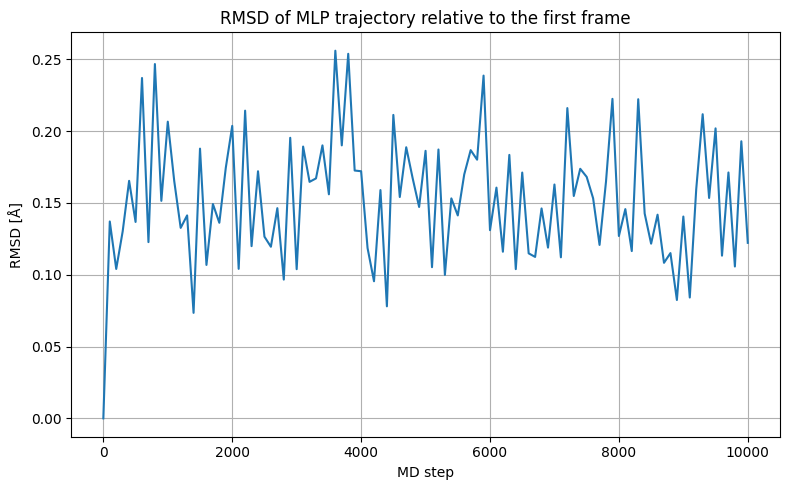

In [ ]:
# =========================
# 3. RMSD względem pierwszej struktury
# =========================

def get_coords(frame):
    return frame[["x", "y", "z"]].values

ref_coords = get_coords(frames[0])

rmsd_values = []

for frame in frames:
    coords = get_coords(frame)
    diff = coords - ref_coords
    rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    rmsd_values.append(rmsd)

rmsd_values = np.array(rmsd_values)

rmsd_df = pd.DataFrame({
    "Step": timesteps,
    "RMSD_A": rmsd_values
})

display(rmsd_df.head())

rmsd_csv = os.path.join(mlp_dir, "rmsd_vs_first_frame.csv")
rmsd_df.to_csv(rmsd_csv, index=False)
print("Saved:", rmsd_csv)

plt.figure(figsize=(8, 5))
plt.plot(rmsd_df["Step"], rmsd_df["RMSD_A"])
plt.xlabel("MD step")
plt.ylabel("RMSD [Å]")
plt.title("RMSD of MLP trajectory relative to the first frame")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "mlp_rmsd_vs_first_frame.png"), dpi=300)
plt.show()

Detected bond distances:


,Step,Atom_i,Atom_j,Bond_type,Distance_A
0,0,1,2,C-H,1.117979
1,0,2,3,C-O,1.235849
2,0,2,4,C-O,1.306259
3,0,7,8,C-O,1.306144
4,0,8,9,C-O,1.235877


Number of detected distances: 606
Saved: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/mlp_bond_distances.csv


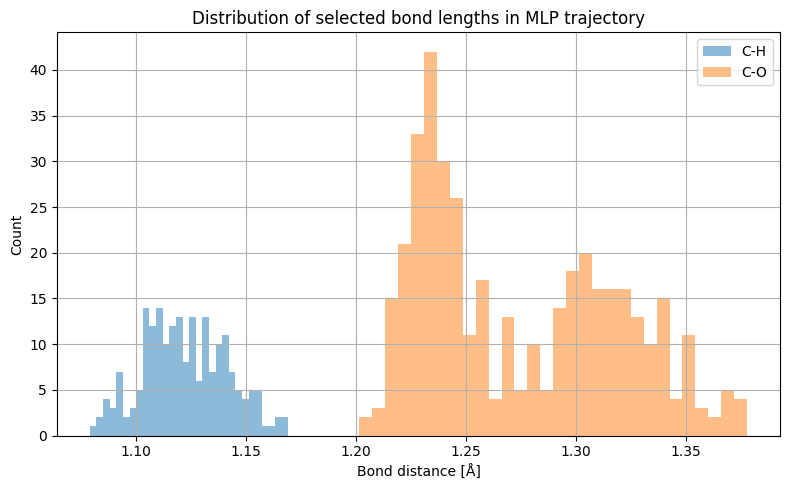

In [ ]:
# =========================
# 4. Długości wiązań
# =========================
# Uwaga:
# atom types: 1 = H, 2 = C, 3 = O
# Tu automatycznie zbieramy krótkie odległości typowe dla wiązań:
# C-H, C-O, O-H

type_map = {
    1: "H",
    2: "C",
    3: "O"
}

def distance(a, b):
    return np.linalg.norm(a - b)

bond_records = []

# Kryteria odległości, żeby wyłapać typowe wiązania w kwasie mrówkowym
bond_rules = {
    ("C", "H"): (0.8, 1.3),
    ("C", "O"): (1.0, 1.6),
    ("O", "H"): (0.7, 1.2)
}

for step, frame in zip(timesteps, frames):
    coords = frame[["x", "y", "z"]].values
    types = frame["type"].values
    ids = frame["id"].values

    for i in range(len(frame)):
        for j in range(i + 1, len(frame)):
            elem_i = type_map[types[i]]
            elem_j = type_map[types[j]]

            pair = tuple(sorted([elem_i, elem_j]))
            d = distance(coords[i], coords[j])

            if pair in bond_rules:
                d_min, d_max = bond_rules[pair]
                if d_min <= d <= d_max:
                    bond_records.append({
                        "Step": step,
                        "Atom_i": ids[i],
                        "Atom_j": ids[j],
                        "Bond_type": f"{pair[0]}-{pair[1]}",
                        "Distance_A": d
                    })

bond_df = pd.DataFrame(bond_records)

print("Detected bond distances:")
display(bond_df.head())
print("Number of detected distances:", len(bond_df))

bond_csv = os.path.join(mlp_dir, "mlp_bond_distances.csv")
bond_df.to_csv(bond_csv, index=False)
print("Saved:", bond_csv)

plt.figure(figsize=(8, 5))

for bond_type in sorted(bond_df["Bond_type"].unique()):
    subset = bond_df[bond_df["Bond_type"] == bond_type]
    plt.hist(subset["Distance_A"], bins=30, alpha=0.5, label=bond_type)

plt.xlabel("Bond distance [Å]")
plt.ylabel("Count")
plt.title("Distribution of selected bond lengths in MLP trajectory")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "mlp_bond_length_histogram.png"), dpi=300)
plt.show()

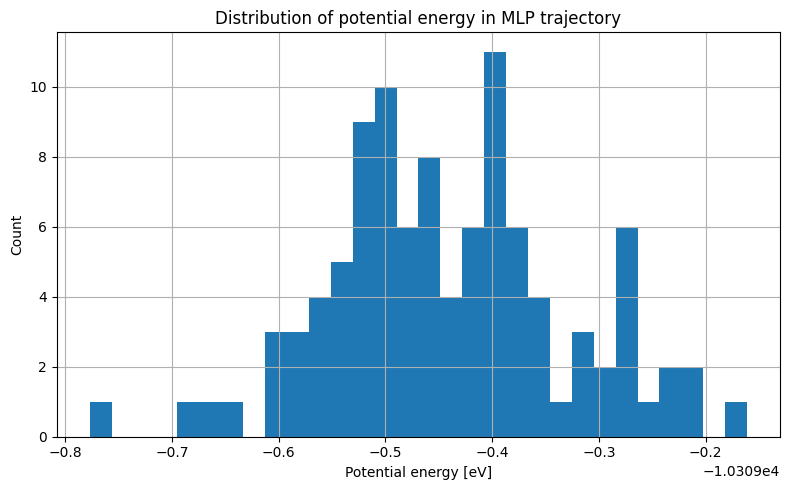

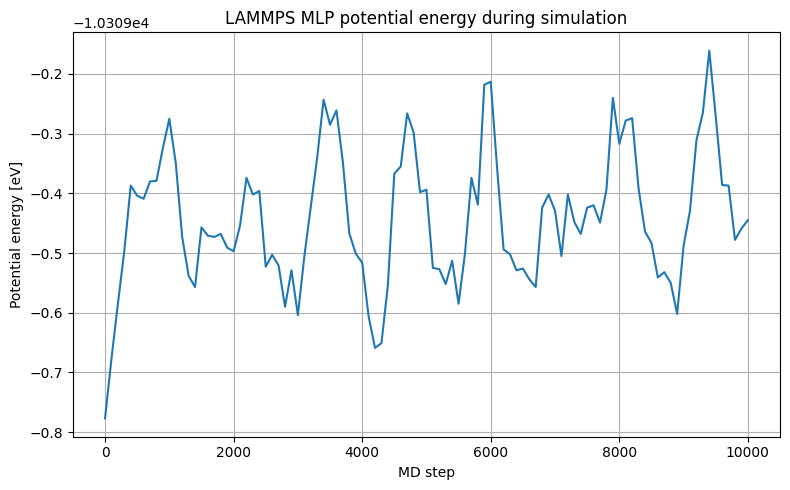

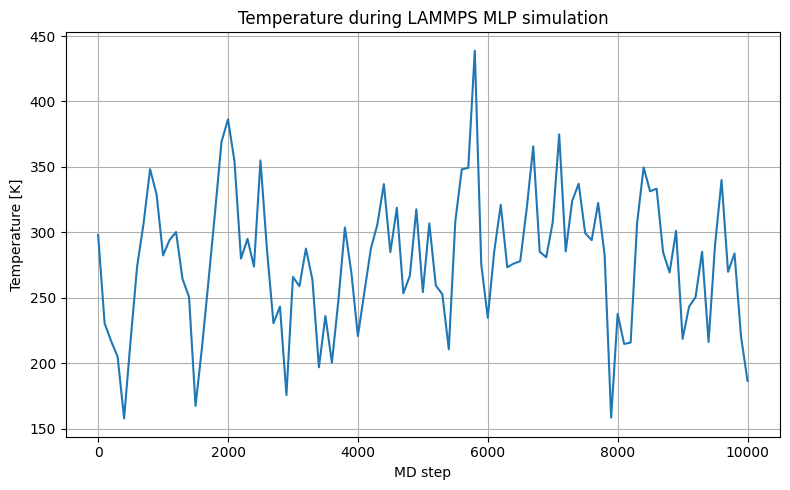

In [ ]:
# =========================
# 5. Rozkład energii z trajektorii MLP
# =========================

plt.figure(figsize=(8, 5))
plt.hist(log_df["PotEng"], bins=30)
plt.xlabel("Potential energy [eV]")
plt.ylabel("Count")
plt.title("Distribution of potential energy in MLP trajectory")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "mlp_potential_energy_histogram.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(log_df["Step"], log_df["PotEng"])
plt.xlabel("MD step")
plt.ylabel("Potential energy [eV]")
plt.title("LAMMPS MLP potential energy during simulation")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "mlp_potential_energy_vs_step.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(log_df["Step"], log_df["Temp"])
plt.xlabel("MD step")
plt.ylabel("Temperature [K]")
plt.title("Temperature during LAMMPS MLP simulation")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "mlp_temperature_vs_step.png"), dpi=300)
plt.show()

In [ ]:
# =========================
# 6. Podsumowanie zapisanych wykresów
# =========================

print("Plots saved in:")
print(plots_dir)

print("\nGenerated plot files:")
for file in os.listdir(plots_dir):
    if file.endswith(".png"):
        print(file)

Plots saved in:
/content/gdrive/MyDrive/ML/task-2/mlp_simulation/lammps_plots

Generated plot files:
mlp_rmsd_vs_first_frame.png
mlp_bond_length_histogram.png
mlp_potential_energy_histogram.png
mlp_potential_energy_vs_step.png
mlp_temperature_vs_step.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mlp_dir = "/content/gdrive/MyDrive/ML/task-2/mlp_simulation"

dump_path = os.path.join(mlp_dir, "fad_mlp.dump")
log_path = os.path.join(mlp_dir, "log.lammps")
plots_dir = os.path.join(mlp_dir, "lammps_plots")

os.makedirs(plots_dir, exist_ok=True)

print("fad_mlp.dump exists:", os.path.exists(dump_path))
print("log.lammps exists:", os.path.exists(log_path))

fad_mlp.dump exists: True
log.lammps exists: True


In [ ]:
def read_lammps_dump(dump_path):
    frames = []
    timesteps = []

    with open(dump_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if lines[i].strip() == "ITEM: TIMESTEP":
            step = int(lines[i + 1].strip())
            natoms = int(lines[i + 3].strip())

            atom_header_idx = None
            for j in range(i, min(i + 20, len(lines))):
                if lines[j].startswith("ITEM: ATOMS"):
                    atom_header_idx = j
                    break

            columns = lines[atom_header_idx].split()[2:]
            atom_lines = lines[atom_header_idx + 1 : atom_header_idx + 1 + natoms]

            frame = pd.DataFrame(
                [line.split() for line in atom_lines],
                columns=columns
            )

            for col in frame.columns:
                frame[col] = pd.to_numeric(frame[col])

            frame = frame.sort_values("id").reset_index(drop=True)

            timesteps.append(step)
            frames.append(frame)

            i = atom_header_idx + 1 + natoms
        else:
            i += 1

    return np.array(timesteps), frames


timesteps, frames = read_lammps_dump(dump_path)

print("Number of frames:", len(frames))
print("Number of atoms:", len(frames[0]))
print("First timesteps:", timesteps[:10])
display(frames[0])

Number of frames: 101
Number of atoms: 10
First timesteps: [  0 100 200 300 400 500 600 700 800 900]


,id,type,x,y,z
0,1,1,13.1413,17.3196,15.0130
1,2,2,13.8428,16.4491,15.0150
2,3,3,14.5111,16.1810,16.0194
3,4,3,13.8445,15.8094,13.8761
4,5,1,14.5052,15.0085,13.9134
5,6,1,15.4956,14.9921,16.0863
6,7,3,16.1558,14.1908,16.1237
7,8,2,16.1570,13.5508,14.9851
8,9,3,15.4893,13.8194,13.9804
9,10,1,16.8573,12.6792,14.9876


,Step,RMSD_A
0,0,0.000000
1,100,0.137095
2,200,0.104046
3,300,0.130192
4,400,0.165396


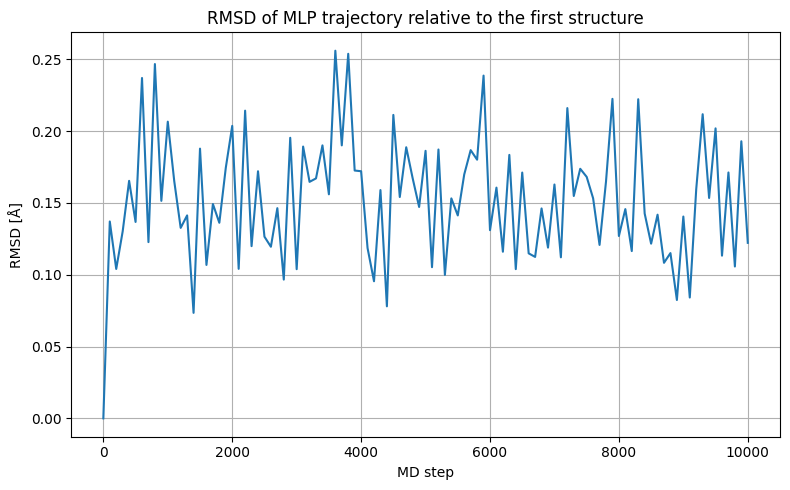

Saved RMSD plot: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/lammps_plots/mlp_rmsd_vs_first_structure.png


In [ ]:
def get_coords(frame):
    return frame[["x", "y", "z"]].to_numpy()

ref = get_coords(frames[0])

rmsd = []

for frame in frames:
    coords = get_coords(frame)
    diff = coords - ref
    value = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    rmsd.append(value)

rmsd = np.array(rmsd)

rmsd_df = pd.DataFrame({
    "Step": timesteps,
    "RMSD_A": rmsd
})

display(rmsd_df.head())

plt.figure(figsize=(8, 5))
plt.plot(rmsd_df["Step"], rmsd_df["RMSD_A"])
plt.xlabel("MD step")
plt.ylabel("RMSD [Å]")
plt.title("RMSD of MLP trajectory relative to the first structure")
plt.grid(True)
plt.tight_layout()

rmsd_plot_path = os.path.join(plots_dir, "mlp_rmsd_vs_first_structure.png")
plt.savefig(rmsd_plot_path, dpi=300)
plt.show()

print("Saved RMSD plot:", rmsd_plot_path)

In [ ]:
def read_lammps_log(log_path):
    rows = []
    header = None
    reading = False

    with open(log_path, "r") as f:
        for line in f:
            parts = line.split()

            if len(parts) >= 5 and parts[0] == "Step" and "Temp" in parts and "PotEng" in parts:
                header = parts
                reading = True
                continue

            if reading:
                try:
                    values = [float(x) for x in parts]
                    if len(values) == len(header):
                        rows.append(values)
                    else:
                        reading = False
                except:
                    reading = False

    return pd.DataFrame(rows, columns=header)


log_df = read_lammps_log(log_path)

print("Columns in log:")
print(log_df.columns.tolist())

display(log_df.head())
display(log_df.tail())

Columns in log:
['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng']


,Step,Temp,PotEng,KinEng,TotEng
0,0.0,298.00000,-10309.777,0.346676,-10309.430
1,100.0,230.49855,-10309.677,0.268148,-10309.408
2,200.0,216.97560,-10309.585,0.252417,-10309.333
3,300.0,205.02580,-10309.496,0.238515,-10309.257
4,400.0,157.89729,-10309.387,0.183688,-10309.203


,Step,Temp,PotEng,KinEng,TotEng
96,9600.0,339.99017,-10309.386,0.395525,-10308.991
97,9700.0,269.84943,-10309.387,0.313927,-10309.073
98,9800.0,283.84356,-10309.478,0.330207,-10309.147
99,9900.0,220.36091,-10309.459,0.256355,-10309.203
100,10000.0,186.53661,-10309.445,0.217006,-10309.228


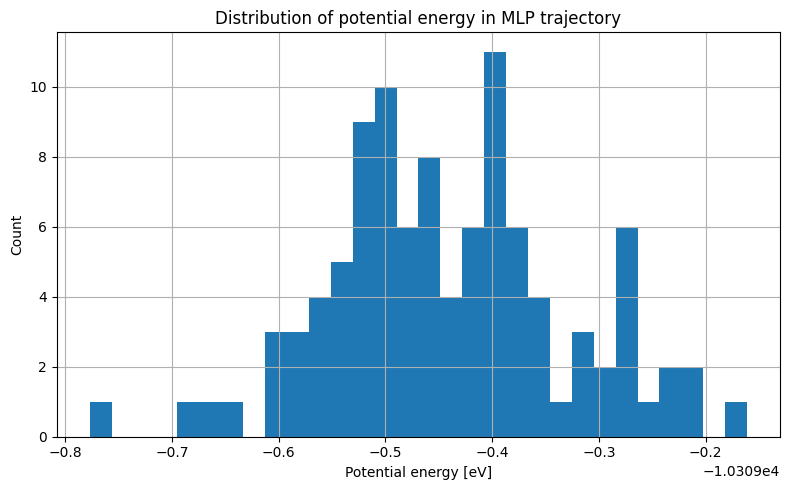

Saved energy distribution plot: /content/gdrive/MyDrive/ML/task-2/mlp_simulation/lammps_plots/mlp_potential_energy_distribution.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(log_df["PotEng"], bins=30)
plt.xlabel("Potential energy [eV]")
plt.ylabel("Count")
plt.title("Distribution of potential energy in MLP trajectory")
plt.grid(True)
plt.tight_layout()

energy_hist_path = os.path.join(plots_dir, "mlp_potential_energy_distribution.png")
plt.savefig(energy_hist_path, dpi=300)
plt.show()

print("Saved energy distribution plot:", energy_hist_path)